In [108]:
from pathlib import Path
import lib_config as config

import os
import json
import numpy as np
import pandas as pd

import lib_gp
import lib_grad
import lib_grad_db
import lib_random
import lib_ga
import lib_ga_db
import lib_backbone
import lib_plot as plot

# desgin
import lib_RFdesign

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [109]:
_config = config._loadConfig(Path("./_config.toml"))
app_config = config.initParams(_config, debug=True)



[Io]
  filename_input      : params.csv
  filename_output     : results.csv
  filename_temp       : temp_hfss_export.csv

[Opt]
  kernel_type         : RBF
  length_scale        : 1.000000
  noise_std           : 0.010000
  noise_var           : 0.000100

[Hfss]
  n_simulation        : 100
  n_repeats           : 5
  n_init              : 20
  n_params            : 13
  lower_bounds        : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 2, 2, 1]
  upper_bounds        : [10.0, 10.0, 10.0, 10.0, 10.0, 2.0, 2.0, 2.0, 2.0, 2.0, 7, 7, 6]
  param_names         : ['h1', 'h2', 'h3', 'h4', 'h5', 's1', 's2', 's3', 's4', 's5', 'a', 'b', 'k']
  param_units         : ['mm', 'mm', 'mm', 'mm', 'mm', '', '', '', '', '', 'mm', 'mm', '']
  filename_models     : ['Backshort.step', 'Finshape.step']
  param_groups        : {'A': {'param_names': ['h1', 'h2', 'h3', 'h4', 'h5', 's1', 's2', 's3', 's4', 's5'], 'param_units': ['mm', 'mm', 'mm', 'mm', 'mm', '', '', '', '', ''], 'lower_bounds': [1.0, 1.0, 1.

In [110]:
backbone = lib_backbone.Backbone(config = app_config)
gp = lib_gp.GaussianProcess(config = app_config)

def build_optimizer(method, config):
    if method == "gp":
        return lib_gp.GaussianProcess(config=config)
    if method == "gradient":
        return lib_grad.GradientSearch(config=config)
    if method == "gradient_db":
        return lib_grad_db.GradientSearch(config=config)
    if method == "random":
        return lib_random.RandomSearch(config=config)
    if method == "ga":
        return lib_ga.RealCodedGA(config=config)
    if method == "ga_db":
        return lib_ga_db.RealCodedGA(config=config)
    raise ValueError(f"Unknown optimizer method: {method}")

base_dir = app_config.env.dir_base
backbone.initStorer()


Created new run directory: T:\RAkizawa\HFSS_C2WR10\src\0413191156
HDF5 dataset created at: T:\RAkizawa\HFSS_C2WR10\src\0413191156\results.h5


In [111]:
model_paths, model_paths_str = backbone._get_path_models()


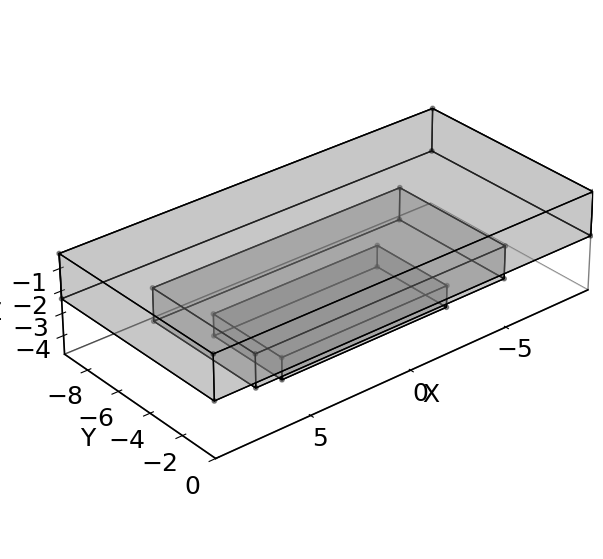

In [112]:
design = lib_RFdesign.ConvexBackshort(model_path=model_paths[0])
step_info = design.genStepBackshort(step_heights=(2.0, 1.5, 1.0), shrink=1.5)
design.plotStepBackshort3D(step_info)

# original smooth backshort example (commented coexistence)
# convex_backshort = design.genBackshort()
# design.plotConvex3D(convex_backshort)


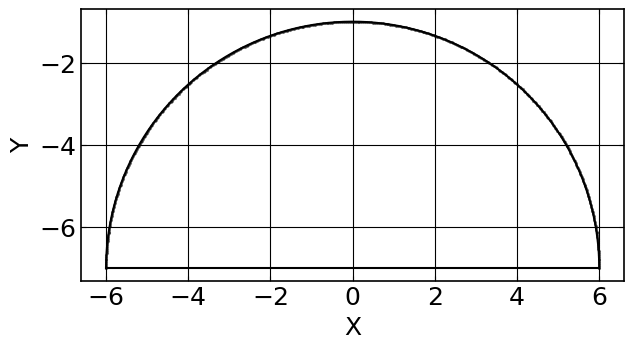

In [113]:
design = lib_RFdesign.ConvexFinshape(model_path=model_paths[1])
convex_finshpe = design.genFinshape()
design.plotProfile2D(convex_finshpe)


In [114]:
RESULTS_FILE = str(backbone._get_dir_run() / Path(_config["io"]["filename_output"]))
TEMP_FILE = str(backbone._get_dir_run() / Path(_config["io"]["filename_temp"]))


In [115]:
def getResult(input_params, param_names, temp_hfss_path, result_file_path):
    df_temp = pd.read_csv(temp_hfss_path)
    header_flag = not os.path.exists(result_file_path)
    
    try:
        s11_value = df_temp.iloc[-1, -1]
        result_row = dict(zip(param_names, input_params))
        result_row["S11"] = s11_value

        df_result = pd.DataFrame([result_row]) # jissainiha kokowo w/o csv de all data fame demo OK
        df_result.to_csv(result_file_path, mode='a', header=header_flag, index=False) # append master file

        try:
            os.remove(temp_hfss_path)
        except OSError:
            pass
        return True
        
    
    except Exception as e:
        print(f"[Error][getResult] Failed to process result: {e}")
        return False


In [116]:
ROUND_DECIMALS = app_config.runtime.round_decimals

# --- A. HFSS ---
def target_hfss(_config_temp, sim_id, param_names, params):
    backbone.call_subroutine(_config_temp, sim_id, param_names, params, value_fmt=f"{{:.{ROUND_DECIMALS}f}}")
    getResult(params, param_names, TEMP_FILE, RESULTS_FILE)
    df_result = pd.read_csv(RESULTS_FILE)
    return df_result.iloc[-1]['S11'] # <--- should be defined as objective param

# --- B. Synthetic Test Function ---
def target_ackley(params):
    
    # --- 2. Calculation ---
    x = np.array(params)
    n = len(params)

    arg1 = -0.2 * np.sqrt((1.0/n) * np.sum(x**2))
    arg2 = (1.0/n) * np.sum(np.cos(2. * np.pi * x))
    
    y = -20. * np.exp(arg1) - np.exp(arg2) + 20. + np.e

    return y

def target_add(params):

    x = np.array(params)

    y = np.sum(params)

    return y

def target_griewank(params):
    
    x = np.array(params)
    n = len(params)

    sum_term = np.sum(x**2) / 4000.0

    indices = np.arange(1, n + 1)
    prod_term = np.prod(np.cos(x / np.sqrt(indices)))
    
    y = 1.0 + sum_term - prod_term
    
    return y

costFunction = target_add
costFunction = target_ackley
costFunction = target_griewank
costFunction = target_hfss

# =====================================
if costFunction == target_hfss:
    cfg = app_config.hfss
elif costFunction == target_ackley:
    cfg = app_config.test
elif costFunction == target_add:
    cfg = app_config.test
elif costFunction == target_griewank:
    cfg = app_config.test


def round_params(params, decimals=ROUND_DECIMALS):
    return np.round(np.asarray(params, dtype=float).flatten(), decimals)


def round_history_row(row, param_names, decimals=ROUND_DECIMALS):
    rounded = dict(row)
    for name in param_names:
        if name in rounded:
            rounded[name] = float(np.round(rounded[name], decimals))
    if 'S11' in rounded:
        rounded['S11'] = float(np.round(rounded['S11'], decimals))
    if 'Metric' in rounded and pd.notna(rounded['Metric']):
        rounded['Metric'] = float(np.round(rounded['Metric'], decimals))
    if 'gamma' in rounded and pd.notna(rounded['gamma']):
        rounded['gamma'] = float(np.round(rounded['gamma'], decimals))
    return rounded


LOWER_BOUNDS = cfg.lower_bounds
UPPER_BOUNDS = cfg.upper_bounds
PARAM_NAMES = cfg.param_names
N_REPT = cfg.n_repeats
N_INIT = cfg.n_init
N_SIML = cfg.n_simulation



In [117]:
if cfg.n_simulation <= cfg.n_init:
    raise ValueError("n_simulation must be greater than n_init.")


In [118]:
backbone._get_path_models()[0]


[WindowsPath('T:/RAkizawa/HFSS_C2WR10/src/0413191156/Backshort.step'),
 WindowsPath('T:/RAkizawa/HFSS_C2WR10/src/0413191156/Finshape.step')]

In [119]:
_config_temp = {
"n_simulation": cfg.n_simulation,
"n_repeats": cfg.n_repeats,
#"param_names": cfg.param_names[:4],
#"param_units": cfg.param_units[:4],
"WATCH_DIR": str(backbone._get_dir_run()),
"INPUT_FILE": str(backbone._get_dir_run() / Path(_config["io"]["filename_input"])),
"MODEL_FILE": model_paths_str,
"RESULTS_FILE": str(backbone._get_dir_run() / Path(_config["io"]["filename_output"])),
"TEMP_FILE": str(backbone._get_dir_run() / Path(_config["io"]["filename_temp"])),
"DONE_FLAG_FILE": str(backbone._get_dir_run() / Path("hfss.done")),
}

done_flag_path = Path(_config_temp["DONE_FLAG_FILE"])
done_flag_path.unlink(missing_ok=True)

with open(base_dir / Path("_config_HFSS.json"), 'w') as f:
        json.dump(_config_temp , f, indent=4)

print(f"Temporarily updated '{base_dir / Path("_config_HFSS.json")}' with run-specific WATCH_DIR for HFSS.")


Temporarily updated 'T:\RAkizawa\HFSS_C2WR10\src\_config_HFSS.json' with run-specific WATCH_DIR for HFSS.


In [120]:
def costFunctionWrapper(param_names, params,):

    params = round_params(params, decimals=ROUND_DECIMALS)
    sim_id = backbone._getSimulationID()
    
    y = costFunction(_config_temp, sim_id, param_names, params,)
       
    # output
    _newline = dict(zip(param_names, params))
    _newline['S11'] = float(np.round(y, ROUND_DECIMALS))
    _newline = round_history_row(_newline, param_names)

    return y, _newline



In [ ]:
# Optimizer

SEARCH_METHOD = "gp"
optimizer = build_optimizer(SEARCH_METHOD, app_config)

def _build_hidden_row(row, routine_idx, method_name):
    hidden_row = dict(row)
    hidden_row["routine_idx"] = routine_idx
    hidden_row["method"] = method_name
    hidden_row["visibility"] = "hidden"
    return round_history_row(hidden_row, PARAM_NAMES)


def _save_hidden_history(debug_rows, repeat_idx):
    if not debug_rows:
        return None

    df_debug = pd.DataFrame(debug_rows)
    csv_path = backbone._get_dir_run() / f"debug_repeat_{repeat_idx}.csv"
    df_debug.to_csv(csv_path, index=False)
    print(f"Saved hidden debug rows to: {csv_path}")
    return csv_path


def _append_visible_row(row, visible_history, routine_idx, info):
    row_visible = round_history_row(row, PARAM_NAMES)
    row_visible['Metric'] = float(np.round(info.get('base_y', np.nan), ROUND_DECIMALS)) if pd.notna(info.get('base_y', np.nan)) else np.nan
    row_visible['gamma'] = float(np.round(info.get('gamma', info.get('length_scale', np.nan)), ROUND_DECIMALS)) if pd.notna(info.get('gamma', info.get('length_scale', np.nan))) else np.nan
    row_visible['routine_idx'] = routine_idx
    visible_history.append(row_visible)


def optBySearch(n_simulation, history_data, visible_history, hidden_history, initial_rows, lower_bound, upper_bound, active_indices=None, fixed_point=None):

    initial_count = len(initial_rows)
    total_budget = max(0, n_simulation - initial_count)
    if total_budget == 0:
        print("[search budget] no remaining simulation budget after initialization")
        return

    if not initial_rows:
        print("[search budget] no seed rows available for optimizer search")
        return

    if SEARCH_METHOD == "gradient_db":
        seed_row = dict(min(initial_rows, key=lambda row: row["S11"]))
        seed_label = "best_initial"
        remaining_budget = total_budget
        routine_idx = 1

        #print(
        #    f"[search routine] entering {routine_idx}/1 "
        #    f"(remaining budget incl. this: {remaining_budget}, seed: {seed_label}, n_init: {initial_count})"
        #)

        x_new, info = optimizer.search(
            history_data=history_data,
            param_names=PARAM_NAMES,
            lower_bounds=lower_bound,
            upper_bounds=upper_bound,
            objective_func=costFunctionWrapper,
            active_indices=active_indices,
            fixed_point=fixed_point,
            routine_index=routine_idx,
            routine_total=1,
            start_row=seed_row,
            maxiter=max(1, remaining_budget),
            maxfun=remaining_budget,
            max_evals=remaining_budget,
        )

        if x_new is not None:
            pre_row = dict(zip(PARAM_NAMES, np.asarray(x_new, dtype=float).flatten()))
            pre_row["S11"] = np.nan
            pre_row["phase"] = "x_new_pre_eval"
            hidden_history.append(_build_hidden_row(pre_row, routine_idx, "pre_eval"))

        method_name = info.get('method', SEARCH_METHOD)
        evaluated_rows = info.get('evaluated_rows', [])
        if not evaluated_rows and x_new is not None:
            _, fallback_row = costFunctionWrapper(PARAM_NAMES, x_new)
            evaluated_rows = [fallback_row]

        for row in evaluated_rows:
            rounded_row = round_history_row(row, PARAM_NAMES)
            history_data.append(rounded_row)
            hidden_history.append(_build_hidden_row(rounded_row, routine_idx, method_name))
            _append_visible_row(rounded_row, visible_history, routine_idx, info)

        if not evaluated_rows:
            print("[search routine] stopped at 1/1 because the optimizer produced no new evaluations")
            return

        print("[search routine] exited 1/1 (remaining budget: 0)")
        print(f"{routine_idx:<5} | {float(np.round(info.get('base_y', np.nan), ROUND_DECIMALS)):<10} | {method_name:<10} | {float(np.round(info.get('gamma', info.get('length_scale', np.nan)), ROUND_DECIMALS)) if pd.notna(info.get('gamma', info.get('length_scale', np.nan))) else np.nan}")
        return

    routine_idx = 0
    while routine_idx < total_budget:
        used_budget = max(0, len(visible_history) - initial_count)
        remaining_budget = total_budget - used_budget
        if remaining_budget <= 0:
            print(f"[search budget] exhausted after routine {routine_idx}")
            break

        routine_idx += 1
        if routine_idx <= len(initial_rows):
            seed_row = dict(initial_rows[routine_idx - 1])
            seed_label = f"initial[{routine_idx - 1}]"
        else:
            seed_row = dict(min(history_data, key=lambda row: row["S11"]))
            seed_label = "best_so_far"

        #print(
        #    f"[search routine] entering {routine_idx}/{total_budget} "
        #    f"(remaining budget incl. this: {remaining_budget}, seed: {seed_label})"
        #)

        x_new, info = optimizer.search(
            history_data=history_data,
            param_names=PARAM_NAMES,
            lower_bounds=lower_bound,
            upper_bounds=upper_bound,
            objective_func=costFunctionWrapper,
            active_indices=active_indices,
            fixed_point=fixed_point,
            routine_index=routine_idx,
            routine_total=total_budget,
            start_row=seed_row,
            maxiter=max(1, remaining_budget),
            maxfun=remaining_budget,
            max_evals=remaining_budget,
        )

        # 追加: x_new を先に記録（評価結果がなくても残す）
        if x_new is not None:
            pre_row = dict(zip(PARAM_NAMES, np.asarray(x_new, dtype=float).flatten()))
            pre_row["S11"] = np.nan
            pre_row["phase"] = "x_new_pre_eval"
            hidden_history.append(_build_hidden_row(pre_row, routine_idx, "pre_eval"))

        method_name = info.get('method', SEARCH_METHOD)
        evaluated_rows = info.get('evaluated_rows', [])
        if not evaluated_rows and x_new is not None:
            _, fallback_row = costFunctionWrapper(PARAM_NAMES, x_new)
            evaluated_rows = [fallback_row]

        for row in evaluated_rows:
            rounded_row = round_history_row(row, PARAM_NAMES)
            history_data.append(rounded_row)
            hidden_history.append(_build_hidden_row(rounded_row, routine_idx, method_name))
            _append_visible_row(rounded_row, visible_history, routine_idx, info)

        if not evaluated_rows:
            print(
                f"[search routine] stopped at {routine_idx}/{total_budget} "
                "because the optimizer produced no new evaluations"
            )
            break

        print(
            f"[search routine] exited {routine_idx}/{total_budget} "
            f"(remaining budget: {total_budget - max(0, len(visible_history) - initial_count)})"
        )
        print(f"{routine_idx:<5} | {float(np.round(info.get('base_y', np.nan), ROUND_DECIMALS)):<10} | {method_name:<10} | {float(np.round(info.get('gamma', info.get('length_scale', np.nan)), ROUND_DECIMALS)) if pd.notna(info.get('gamma', info.get('length_scale', np.nan))) else np.nan}")


Active Indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Fixed Point: [2.  2.  2.  2.  2.  1.  0.2 0.2 0.2 0.2 4.  6.  2. ]

Starting gp Repeat 1/5

--- Generating 20 Initial Samples ---
Iter  | New y      | Method     | Metric
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
[search routine] exited 1/80 (remaining budget: 79)
1     | nan        | gp         | 879.1269845721
  > Result receive

c:\Users\Suzuki Lab 10\AppData\Local\Programs\Python\Python312\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
c:\Users\Suzuki Lab 10\AppData\Local\Programs\Python\Python312\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
c:\Users\Suzuki Lab 10\AppData\Local\Programs\Python\Python312\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
c:\Users\Suzuki Lab 10\AppData\Local\Programs\Python\Python312\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(
c:\Users\Suzuki Lab 10\AppData\Local\Programs\Python\Python312\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-04 to 

  > Result received from HFSS.
[search routine] exited 52/80 (remaining budget: 28)
52    | nan        | gp         | 7.3562741137
  > Result received from HFSS.
[search routine] exited 53/80 (remaining budget: 27)
53    | nan        | gp         | 4.9523183393
  > Result received from HFSS.
[search routine] exited 54/80 (remaining budget: 26)
54    | nan        | gp         | 18.3707465353
  > Result received from HFSS.
[search routine] exited 55/80 (remaining budget: 25)
55    | nan        | gp         | 9.465552695
  > Result received from HFSS.
[search routine] exited 56/80 (remaining budget: 24)
56    | nan        | gp         | 52.0766952754
  > Result received from HFSS.
[search routine] exited 57/80 (remaining budget: 23)
57    | nan        | gp         | 5.8197102632
  > Result received from HFSS.
[search routine] exited 58/80 (remaining budget: 22)
58    | nan        | gp         | 4.4972123725
  > Result received from HFSS.
[search routine] exited 59/80 (remaining budget: 21

c:\Users\Suzuki Lab 10\AppData\Local\Programs\Python\Python312\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
c:\Users\Suzuki Lab 10\AppData\Local\Programs\Python\Python312\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(
c:\Users\Suzuki Lab 10\AppData\Local\Programs\Python\Python312\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
c:\Users\Suzuki Lab 10\AppData\Local\Programs\Python\Python312\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(
c:\Users\Suzuki Lab 10\AppData\Local\Programs\Python\Python312\Lib\site-packages\linear_operator\utils\cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-04 to 

  > Result received from HFSS.
[search routine] exited 76/80 (remaining budget: 4)
76    | nan        | gp         | 23.4024064389
  > Result received from HFSS.
[search routine] exited 77/80 (remaining budget: 3)
77    | nan        | gp         | 40.9564329539
  > Result received from HFSS.
[search routine] exited 78/80 (remaining budget: 2)
78    | nan        | gp         | 35.8612994531
  > Result received from HFSS.
[search routine] exited 79/80 (remaining budget: 1)
79    | nan        | gp         | 8.4429912748
  > Result received from HFSS.
[search routine] exited 80/80 (remaining budget: 0)
80    | nan        | gp         | 8.1522761084
Repeat 19 completed in 5832.600 seconds.
---------------------------------------------------------------------------
Optimization Finished.
Global Best Found: y = -27.9829016010
At location: x = [ 6.4463327218,  1.          ,  2.2921440933, 10.          ,  2.9193779983,
  1.0628334587,  1.3556657697,  2.          ,  2.          ,  2.          ,


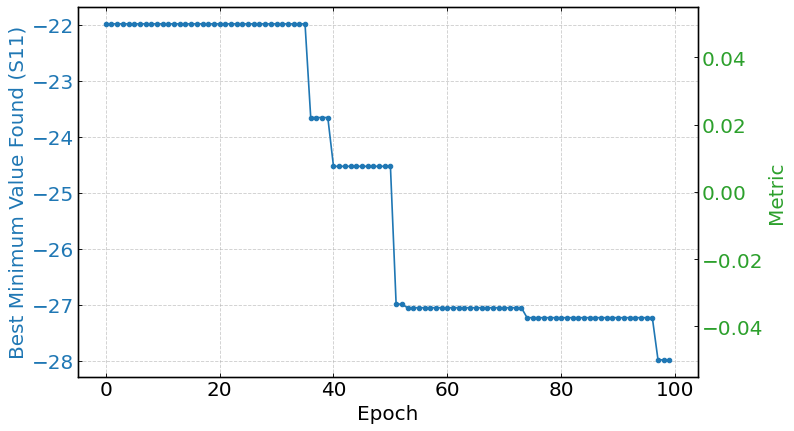


Starting gp Repeat 2/5

--- Generating 20 Initial Samples ---
Iter  | New y      | Method     | Metric
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
[search routine] exited 1/80 (remaining budget: 79)
1     | nan        | gp         | 1560.035121211
  > Result received from HFSS.
[search routine] exited 2/80 (remaining budget: 78)
2     | nan        | gp         | 16.372374782
  > Result rec

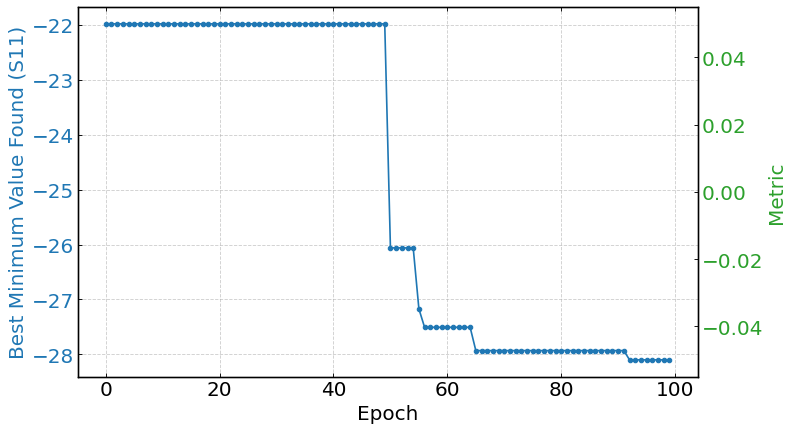


Starting gp Repeat 3/5

--- Generating 20 Initial Samples ---
Iter  | New y      | Method     | Metric
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
[search routine] exited 1/80 (remaining budget: 79)
1     | nan        | gp         | 53.1258992674
  > Result received from HFSS.
[search routine] exited 2/80 (remaining budget: 78)
2     | nan        | gp         | 386.8300720535
  > Result re

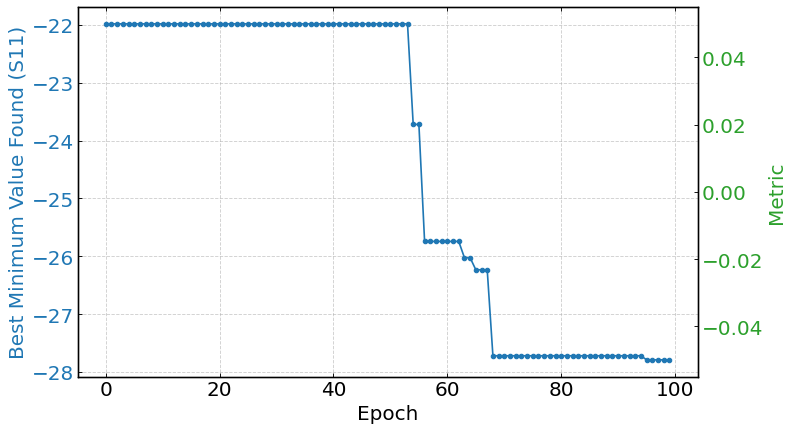


Starting gp Repeat 4/5

--- Generating 20 Initial Samples ---
Iter  | New y      | Method     | Metric
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
[search routine] exited 1/80 (remaining budget: 79)
1     | nan        | gp         | 28.9032821664
  > Result received from HFSS.
[search routine] exited 2/80 (remaining budget: 78)
2     | nan        | gp         | 41.3458905946
  > Result rec

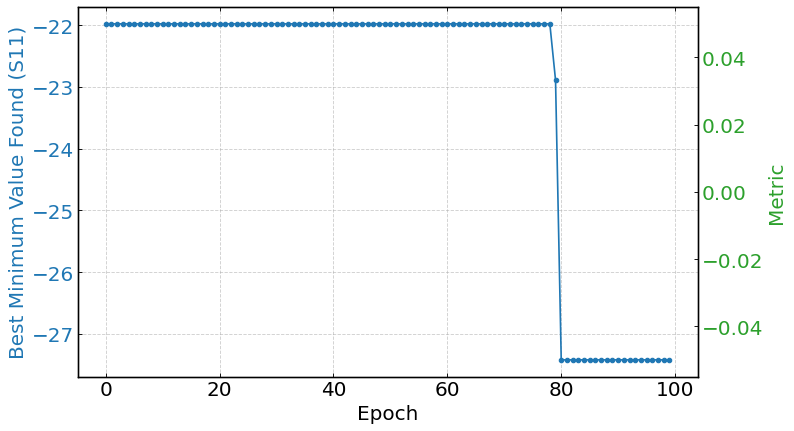


Starting gp Repeat 5/5

--- Generating 20 Initial Samples ---
Iter  | New y      | Method     | Metric
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
  > Result received from HFSS.
[search routine] exited 1/80 (remaining budget: 79)
1     | nan        | gp         | 1180.5473229327
  > Result received from HFSS.
[search routine] exited 2/80 (remaining budget: 78)
2     | nan        | gp         | 626.25070295
  > Result re

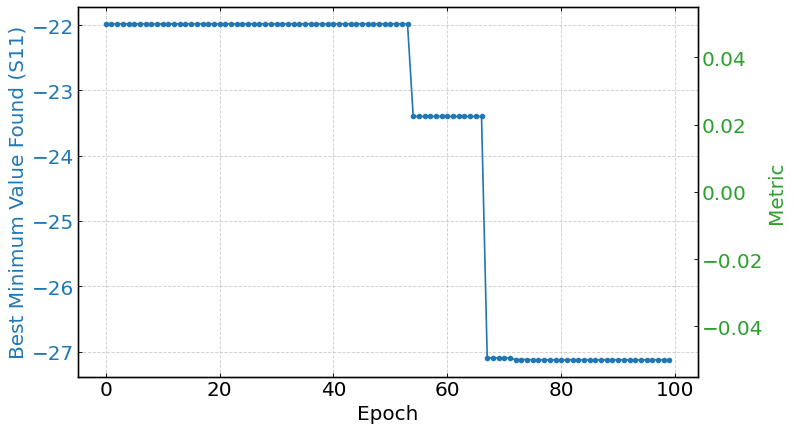

In [122]:
import time
my_best_input = [
    [5.0, 1.503409, 2.285533, 2.441034, 4.919906, 0.0, 1.5, 1.5, 1.5, 1.5, 2.00, 3.627538, 6.00],
]

backbone.all_in_bounds(my_best_input, cfg.lower_bounds, cfg.upper_bounds)
active_indices, fixed_point, _ = backbone._buildSamplingIndices(dims=cfg.n_params, param_groups=cfg.param_groups, group_order=getattr(cfg, "group_order", None),)

print("Active Indices:", active_indices)
print("Fixed Point:", np.round(fixed_point, ROUND_DECIMALS))

try:
    
    for r in range(N_REPT):
        backbone.printn(f"Starting {SEARCH_METHOD} Repeat {r + 1}/{N_REPT}")
        start = time.perf_counter()

        history_data = []
        visible_history = []
        hidden_history = []
        initial_rows = []
        
        # -------------------- initial simulation --------------------------------
        backbone.printn(f"--- Generating {N_INIT} Initial Samples ---")
        
        X_initial = backbone.LHSsampler_extended(
            dims=cfg.n_params,
            nums=cfg.n_init,
            lower_bounds=cfg.lower_bounds,
            upper_bounds=cfg.upper_bounds,
            active_indices=active_indices,
            fixed_point=fixed_point,
            fixed_points = my_best_input # you can also reduce the dim of  my best_input[Ninit:]
        )
        X_initial = np.round(X_initial, ROUND_DECIMALS)
        
        print(f"{'Iter':<5} | {'New y':<10} | {'Method':<10} | {'Metric'}")        
        for i in range(N_INIT):
            params = X_initial[i]

            # add evaluation points
            pre_row = dict(zip(PARAM_NAMES, np.asarray(params, dtype=float).flatten()))
            pre_row["S11"] = np.nan
            pre_row["phase"] = "init_pre_eval"
            hidden_history.append(_build_hidden_row(pre_row, 0, "pre_eval"))

            y_new, _newline = costFunctionWrapper(PARAM_NAMES, params,)
            _newline['Metric'] = np.nan
            _newline['gamma'] = np.nan
            _newline['routine_idx'] = 0
            _newline = round_history_row(_newline, PARAM_NAMES)
            history_data.append(_newline)
            visible_history.append(_newline)
            initial_rows.append(dict(_newline))


        # -------------------- Search --------------------------------
        optBySearch(
            N_SIML,
            history_data,
            visible_history,
            hidden_history,
            initial_rows,
            LOWER_BOUNDS,
            UPPER_BOUNDS,
            active_indices=active_indices,
            fixed_point=fixed_point,
        )

        # ==============================================================================
        elapsed = time.perf_counter() - start
        print(f"Repeat {i} completed in {elapsed:.3f} seconds.")
        
        df_final = pd.DataFrame(visible_history)
        X_train = df_final[PARAM_NAMES].values
        y_train = df_final['S11'].values

        best_idx_final = np.argmin(y_train)
        print("-" * 75)
        print(f"Optimization Finished.")
        print(f"Global Best Found: y = {float(np.round(y_train[best_idx_final], ROUND_DECIMALS)):.10f}")
        
        best_x_str = np.array2string(np.round(X_train[best_idx_final], ROUND_DECIMALS), precision=ROUND_DECIMALS, separator=', ')
        print(f"At location: x = {best_x_str}")
        
        # --- After each repeat, archive results and save plot data ---
        df_output = backbone._genOutputDataFrame(df_final)
        df_output[PARAM_NAMES] = df_output[PARAM_NAMES].round(ROUND_DECIMALS)
        if 'S11' in df_output:
            df_output['S11'] = df_output['S11'].round(ROUND_DECIMALS)
        if 'Metric' in df_output:
            df_output['Metric'] = df_output['Metric'].round(ROUND_DECIMALS)
        if 'gamma' in df_output:
            df_output['gamma'] = df_output['gamma'].round(ROUND_DECIMALS)
        _save_hidden_history(hidden_history, r + 1)
        
        # save
        backbone._addNewDatasetToHDF(df_output, "output", f"repeat_{r+1}")
        
        # --- 5a. Visualize learning curve of the final model ---
        plot.plot_learning_curve(df_output)
        
                
finally:
    done_flag_path = Path(_config_temp["DONE_FLAG_FILE"])
    done_flag_path.touch()

    json_file = base_dir / Path("_config_HFSS.json")
    json_file.unlink(missing_ok=True) # delite the json file
    if backbone.h5f:
        backbone.h5f.close()

